In [1]:
%matplotlib inline
import json, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# correct sentences in neg_evidence L1 (first N are correct, last 1 is incorrect)
N_CORRECT_NEG = 4

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RAW_RUNS_PATH = Path('results/raw_runs.json')

FAMILIES = {
    'deepseek': {'LRM': 'deepseek-r1',            'LLM': 'deepseek-v3'},
    'qwen':     {'LRM': 'qwen3-30b-a3b-think',    'LLM': 'qwen3-30b-a3b'},
    'glm':      {'LRM': 'glm-4.5-think',           'LLM': 'glm-4.5'},
    'claude':   {'LRM': 'claude-sonnet-4.6-think', 'LLM': 'claude-sonnet-4.6'},
    'gemini':   {'LRM': 'gemini-3.5-flash-think',  'LLM': 'gemini-3.5-flash'},
}
MODEL_ORDER = [m for fam in FAMILIES.values() for m in (fam['LRM'], fam['LLM'])]
FAMILY_OF   = {m: fam for fam, members in FAMILIES.items() for m in members.values()}
LRM_MODELS  = {fam['LRM'] for fam in FAMILIES.values()}
LLM_MODELS  = {fam['LLM'] for fam in FAMILIES.values()}

ERR_C  = '#ABB2B9'   # light grey — error bars & significance lines

PAL_PURPLE = ('#3f007d', '#6a51a3')   # LRM / LLM
PAL_BLUE   = ('#07306b', '#2172b5')   # L1 / L2 (production vs induction)
PAL_GREEN  = ('#00441b', '#238b46')   # Depth 4 / Depth 2
PAL_RED    = ('#67000d', '#cc171d')   # Baseline / negative evidence

LRM_C  = PAL_PURPLE[0]
LLM_C  = PAL_PURPLE[1]
L1_C   = PAL_BLUE[1]                  # lighter blue — L1 production bars
L2_BASE_C = PAL_BLUE[0]               # darker blue — generic L2 when unsplit
LRM_D4 = LRM_C
LRM_D2 = LRM_C
LLM_D4 = LLM_C
LLM_D2 = LLM_C
GRN_D  = PAL_GREEN[0]
GRN_L  = PAL_GREEN[1]
BASE_C = PAL_RED[0]
NE_C   = PAL_RED[1]

DEPTH_COLORS = {
    'center_embedding':       {'LRM': LRM_C, 'LLM': LLM_C},
    'center_embedding_depth2':{'LRM': LRM_C, 'LLM': LLM_C},
}

TYPE_COLOR   = {'LRM': LRM_C, 'LLM': LLM_C}
FAMILY_COLOR = {'deepseek': '#2ca02c', 'qwen': '#9467bd', 'glm': '#e377c2',
                'claude': '#d62728', 'gemini': '#1f77b4'}
TEMPLATES_PAPER = ['center_embedding', 'center_embedding_depth2']
TMPL_LABELS = {'center_embedding': 'CE depth 4', 'center_embedding_depth2': 'CE depth 2'}

def bci(vals, n_boot=2000, ci=95):
    """Bootstrap 95% CI. Returns (lo_err, hi_err) relative to mean."""
    if len(vals) < 2:
        return 0.0, 0.0
    vals = np.asarray(vals, dtype=float)
    boots = np.array([np.mean(np.random.choice(vals, len(vals), replace=True))
                      for _ in range(n_boot)])
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    m  = vals.mean()
    return max(0.0, m - lo), max(0.0, hi - m)

def _is_valid_ce(sentence: str, depth: int = 4) -> bool:
    """
    Structural validator — accepts center-embedded patterns:
    Pattern A (bare):       the N the N ... the N  V V ... V        (3*depth words)
    Pattern A+ (phrasal):   same but one verb slot is two words      (3*depth+1 words)
    Pattern B (that):       the N that the N that ... the N  V...V   (4*depth-1 words)
    Pattern B+ (phrasal):   same with one two-word verb              (4*depth words)
    Rejects: 'which'/'who'/'whom'/'whose'/'where', 'and'/'or', wrong structure.
    """
    s = sentence.strip().rstrip('.,!?;')
    if re.search(r'\b(which|who|whom|whose|where)\b', s, re.I):
        return False
    s = s.replace(',', '').replace(';', '')
    if re.search(r'\b(and|or)\b', s, re.I):
        return False
    words = s.lower().split()
    det = {'the', 'a'}

    def np_spine_ok_bare(w, d):
        """NP spine: the N the N ... the N (2*d words)"""
        return all(w[2*i] in det and w[2*i+1].isalpha() for i in range(d))

    def np_spine_ok_that(w, d):
        """NP spine with 'that': the N that the N that ... the N (3*d-1 words)"""
        the_ok  = all(w[3*i] in det and w[3*i+1].isalpha() for i in range(d))
        that_ok = all(w[3*i+2] == 'that' for i in range(d-1))
        return the_ok and that_ok

    COPULAS = {'is', 'are', 'was', 'were', 'be', 'been', 'being',
               'seems', 'seemed', 'appear', 'appeared', 'becomes', 'became'}

    def verbs_ok(w, start, count):
        """All words from start onward are alphabetic and none are copulas."""
        slice_ = w[start:start+count]
        return all(t.isalpha() for t in slice_) and not any(t in COPULAS for t in slice_)

    # Pattern A: bare NP spine (2*depth words) + exactly depth verb words
    if len(words) == 3 * depth and np_spine_ok_bare(words, depth):
        if verbs_ok(words, 2*depth, depth):
            return True

    # Pattern A+: bare NP spine + one extra verb word (one phrasal verb)
    if len(words) == 3 * depth + 1 and np_spine_ok_bare(words, depth):
        if verbs_ok(words, 2*depth, depth+1):
            return True

    # Pattern B: that-NP spine (3*depth-1 words) + exactly depth verb words
    if len(words) == 4 * depth - 1 and np_spine_ok_that(words, depth):
        if verbs_ok(words, 3*depth-1, depth):
            return True

    # Pattern B+: that-NP spine + one extra verb word
    if len(words) == 4 * depth and np_spine_ok_that(words, depth):
        if verbs_ok(words, 3*depth-1, depth+1):
            return True

    return False

def check_validity(sentences: list, template: str) -> list:
    depth = 2 if template == 'center_embedding_depth2' else 4
    return [_is_valid_ce(s, depth=depth) for s in sentences]

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

from pathlib import Path
Path("figures").mkdir(exist_ok=True)


## 1. Load & inspect

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import importlib, prompts
importlib.reload(prompts)
from prompts import build_l1_prompt

# Load only runs for current models (exclude old glm-air runs)
_all_runs = json.loads(RAW_RUNS_PATH.read_text())
runs = [r for r in _all_runs if r.get('model_key') in set(MODEL_ORDER)
        and r.get('template') != 'center_embedding_progressive']
print(f'{len(runs)} run(s) loaded (from {len(_all_runs)} total)\n')

rows = []
for r in runs:
    rows.append({
        'model':          r.get('model_key'),
        'family':         FAMILY_OF.get(r.get('model_key'), 'unknown'),
        'type':           r.get('model_type'),
        'run_idx':        r.get('run_idx'),
        'template':       r.get('template'),
        'induced_prompt': r.get('induced_prompt', ''),
        'error':          r.get('error') or r.get('induction_error'),
    })

df = pd.DataFrame(rows)
df = df[df['model'].isin(MODEL_ORDER)]
print(df.groupby(['model','template'])['induced_prompt'].count().unstack(fill_value=0).to_string())


599 run(s) loaded (from 599 total)

template                 center_embedding  center_embedding_depth2
model                                                             
claude-sonnet-4.6                      30                       30
claude-sonnet-4.6-think                30                       29
deepseek-r1                            29                       30
deepseek-v3                            30                       30
gemini-3.5-flash                       30                       30
gemini-3.5-flash-think                 30                       29
glm-4.5                                30                       30
glm-4.5-think                          30                       30
qwen3-30b-a3b                          30                       30
qwen3-30b-a3b-think                    30                       30


In [3]:
# sentence-level L2 validity flags
val_sent = []
for r in runs:
    tmpl  = r['template']
    depth = 2 if 'depth2' in tmpl else 4
    l2    = r.get('l2_sentences', [])
    for s in l2:
        val_sent.append({
            'model':    r.get('model_key'),
            'family':   FAMILY_OF.get(r.get('model_key'), 'unknown'),
            'type':     r.get('model_type'),
            'template': tmpl,
            'depth':    depth,
            'valid':    float(_is_valid_ce(s, depth)),
        })

sim_df = pd.DataFrame(val_sent)
print(f'val_sent rows: {len(sim_df)}')
print(sim_df.groupby(['model','template'])['valid'].mean().round(3).unstack(fill_value=0).to_string())

# run-level validity rates (unit of analysis for MWU tests)
_run_df_rows = []
for _r in runs:
    _tmpl  = _r['template']
    _model = _r.get('model_key')
    _flags = check_validity(_r.get('l2_sentences', []), _tmpl)
    _rate  = sum(_flags) / len(_flags) if _flags else None
    if _rate is not None:
        _run_df_rows.append({
            'model':    _model,
            'type':     _r.get('model_type'),
            'family':   FAMILY_OF.get(_model, 'unknown'),
            'template': _tmpl,
            'l2_rate':  _rate,
        })
_run_df = pd.DataFrame(_run_df_rows)
print(f'\nRun-level _run_df rows: {len(_run_df)}  (one row per run)')


val_sent rows: 2985
template                 center_embedding  center_embedding_depth2
model                                                             
claude-sonnet-4.6                   0.507                    0.447
claude-sonnet-4.6-think             0.453                    0.600
deepseek-r1                         0.455                    0.933
deepseek-v3                         0.167                    0.527
gemini-3.5-flash                    0.893                    0.740
gemini-3.5-flash-think              0.947                    0.993
glm-4.5                             0.027                    0.033
glm-4.5-think                       0.133                    0.427
qwen3-30b-a3b                       0.593                    0.333
qwen3-30b-a3b-think                 0.700                    0.900

Run-level _run_df rows: 597  (one row per run)


In [4]:
_l1_rows = []
for r in runs:
    tmpl  = r['template']
    depth = 2 if 'depth2' in tmpl else 4
    for s in r.get('l1_sentences', []):
        _l1_rows.append({
            'model': r.get('model_key'), 'type': r.get('model_type'),
            'template': tmpl, 'valid': float(_is_valid_ce(s, depth)),
        })
_l1_df = pd.DataFrame(_l1_rows)

for stage, df_, label_prefix in [('L1', _l1_df, 'L1'), ('L2', sim_df, 'L2')]:
    print(f'{label_prefix} sentence counts (baseline runs only)')
    print('=' * 55)
    for tmpl, label in [('center_embedding', 'CE depth 4'), ('center_embedding_depth2', 'CE depth 2')]:
        sub   = df_[df_['template'] == tmpl]
        total = len(sub)
        acc   = int(sub['valid'].sum())
        rej   = total - acc
        print(f'\n  {label}')
        print(f'    Total sentences : {total}')
        print(f'    Accepted        : {acc}  ({acc/total*100:.1f}%)')
        print(f'    Rejected        : {rej}  ({rej/total*100:.1f}%)')
        print()
        for mtype in ('LRM', 'LLM'):
            ms = sub[sub['type'] == mtype]
            mt = len(ms)
            ma = int(ms['valid'].sum())
            print(f'    {mtype}  accepted {ma}/{mt}  ({ma/mt*100:.1f}%)')
    print()
print()
print('=' * 55)
print('  Per-model breakdown')
print('=' * 55)
pivot = (
    sim_df.groupby(['template', 'model', 'type'])['valid']
    .agg(accepted='sum', total='count')
    .assign(rejected=lambda x: x['total'] - x['accepted'],
            pct_accepted=lambda x: (x['accepted'] / x['total'] * 100).round(1))
    .reset_index()
    .sort_values(['template', 'type', 'pct_accepted'], ascending=[True, True, False])
)
display(pivot[['template','model','type','accepted','rejected','total','pct_accepted']])


L1 sentence counts (baseline runs only)

  CE depth 4
    Total sentences : 1495
    Accepted        : 1468  (98.2%)
    Rejected        : 27  (1.8%)

    LRM  accepted 737/745  (98.9%)
    LLM  accepted 731/750  (97.5%)

  CE depth 2
    Total sentences : 1500
    Accepted        : 1494  (99.6%)
    Rejected        : 6  (0.4%)

    LRM  accepted 746/750  (99.5%)
    LLM  accepted 748/750  (99.7%)

L2 sentence counts (baseline runs only)

  CE depth 4
    Total sentences : 1495
    Accepted        : 729  (48.8%)
    Rejected        : 766  (51.2%)

    LRM  accepted 401/745  (53.8%)
    LLM  accepted 328/750  (43.7%)

  CE depth 2
    Total sentences : 1490
    Accepted        : 882  (59.2%)
    Rejected        : 608  (40.8%)

    LRM  accepted 570/740  (77.0%)
    LLM  accepted 312/750  (41.6%)


  Per-model breakdown


,template,model,type,accepted,rejected,total,pct_accepted
4,center_embedding,gemini-3.5-flash,LLM,134.0,16.0,150,89.3
8,center_embedding,qwen3-30b-a3b,LLM,89.0,61.0,150,59.3
0,center_embedding,claude-sonnet-4.6,LLM,76.0,74.0,150,50.7
3,center_embedding,deepseek-v3,LLM,25.0,125.0,150,16.7
6,center_embedding,glm-4.5,LLM,4.0,146.0,150,2.7
5,center_embedding,gemini-3.5-flash-think,LRM,142.0,8.0,150,94.7
9,center_embedding,qwen3-30b-a3b-think,LRM,105.0,45.0,150,70.0
2,center_embedding,deepseek-r1,LRM,66.0,79.0,145,45.5
1,center_embedding,claude-sonnet-4.6-think,LRM,68.0,82.0,150,45.3
7,center_embedding,glm-4.5-think,LRM,20.0,130.0,150,13.3


## 2. Within-family comparison

L2 structural validity: LRM vs LLM per family. Rows = templates (depth 4 / depth 2), cols = families. Significance bracket shows Mann-Whitney U (two-sided) between LRM and LLM L2 validity.


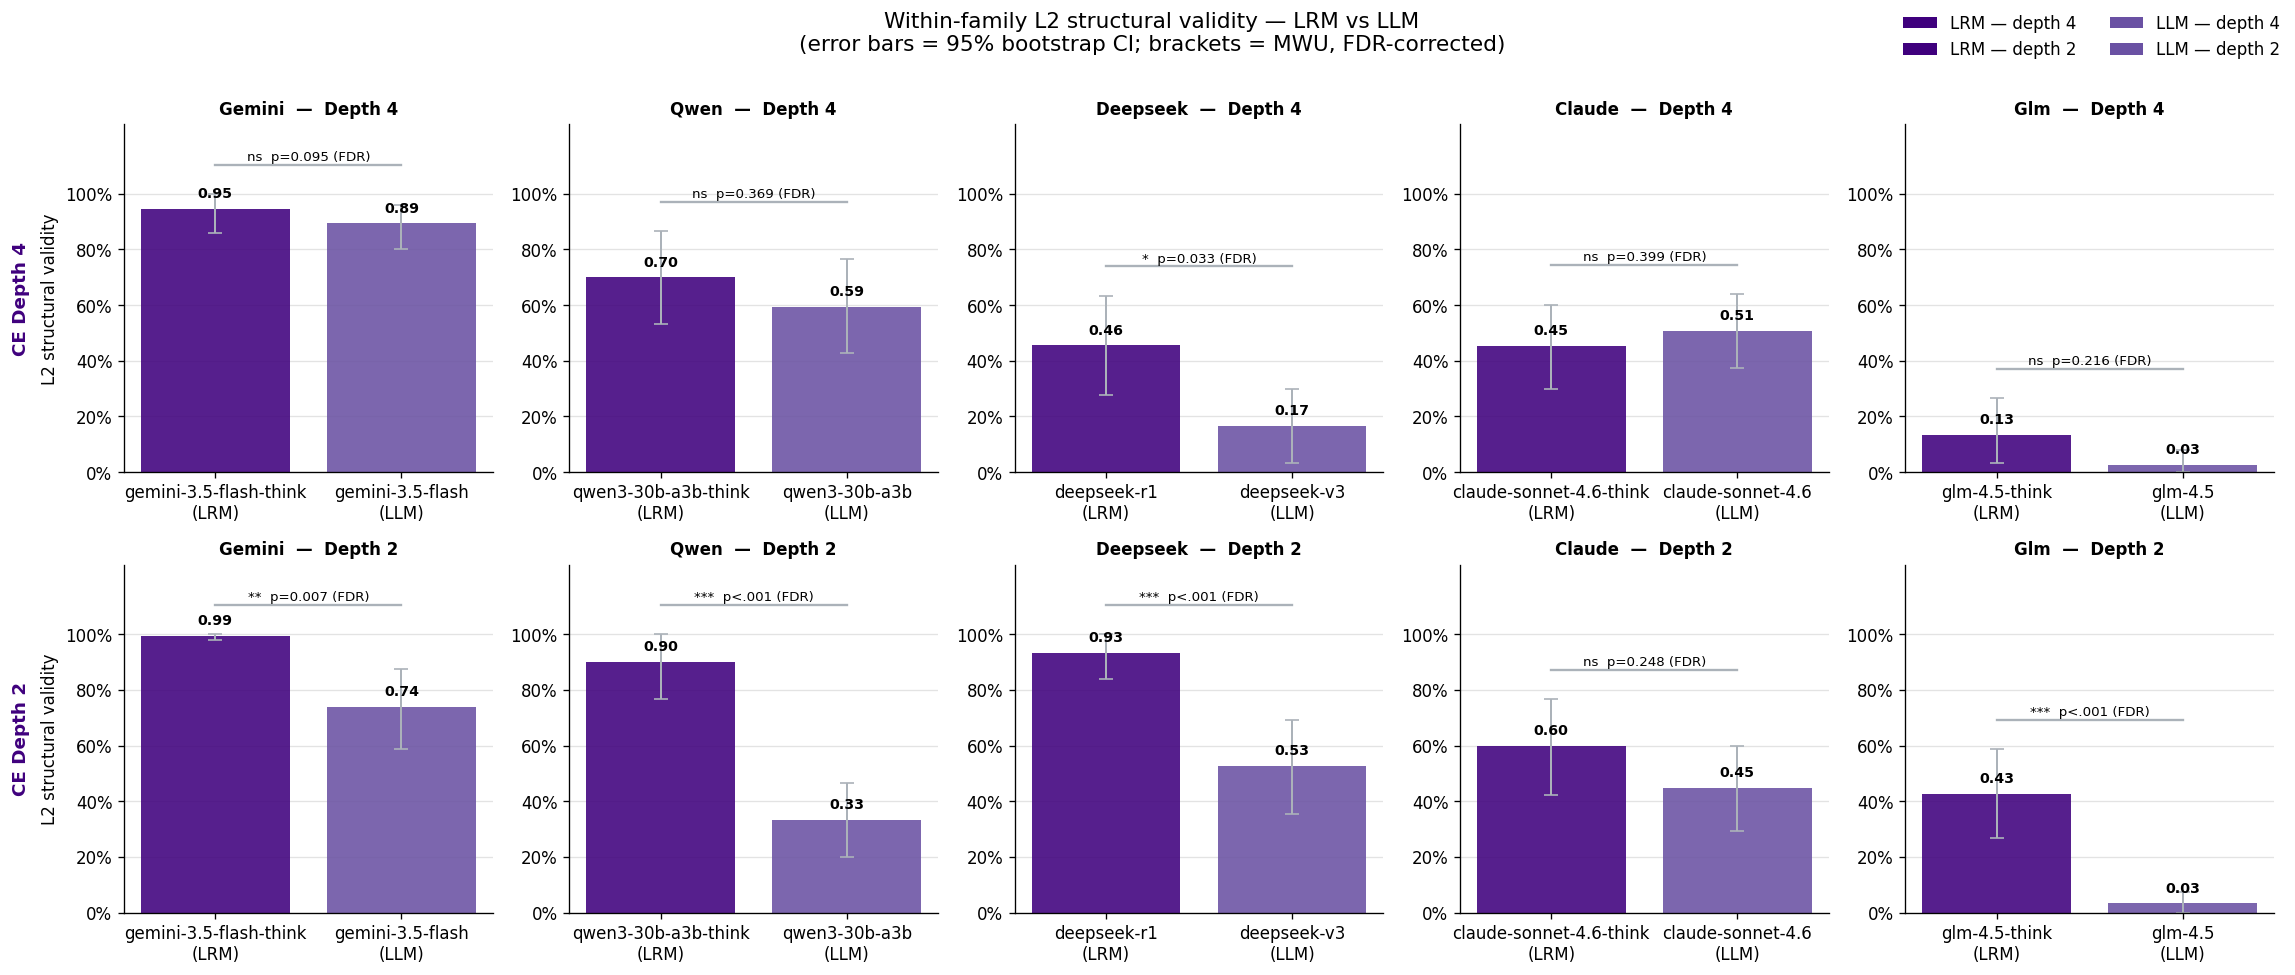

In [5]:

templates_list = ['center_embedding', 'center_embedding_depth2']

# FDR-corrected p-values for all 10 family×template pairs
_fdr_keys, _fdr_raw_ps = [], []
for _tmpl in sorted(_run_df['template'].unique()):
    _t = _run_df[_run_df['template'] == _tmpl]
    for _fam, _mem in FAMILIES.items():
        _lv = _t[_t['model'] == _mem['LRM']]['l2_rate'].dropna().values
        _lv2= _t[_t['model'] == _mem['LLM']]['l2_rate'].dropna().values
        if len(_lv) >= 2 and len(_lv2) >= 2:
            _, _p = stats.mannwhitneyu(_lv, _lv2, alternative='two-sided')
        else:
            _p = float('nan')
        _fdr_keys.append((_tmpl, _fam))
        _fdr_raw_ps.append(_p)
_valid_mask_c = [not np.isnan(p) for p in _fdr_raw_ps]
_, _p_fdr_c, _, _ = multipletests([p for p in _fdr_raw_ps if not np.isnan(p)], method='fdr_bh')
_fdr_iter_c = iter(_p_fdr_c)
_chart_fdr_p = {k: (next(_fdr_iter_c) if v else float('nan'))
                for k, v in zip(_fdr_keys, _valid_mask_c)}

fam_l2 = {}
for fam, members in FAMILIES.items():
    vals = _run_df[_run_df['model'].isin(members.values())]['l2_rate'].dropna()
    fam_l2[fam] = vals.mean()
families_list = sorted(FAMILIES.keys(), key=lambda f: fam_l2[f], reverse=True)

fig, axes = plt.subplots(
    len(templates_list), len(families_list),
    figsize=(3.8 * len(families_list), 4.0 * len(templates_list)),
    squeeze=False
)

for row_i, tmpl in enumerate(templates_list):
    for col_i, fam in enumerate(families_list):
        ax      = axes[row_i][col_i]
        members = FAMILIES[fam]
        dc      = DEPTH_COLORS[tmpl]   # depth-specific {LRM: color, LLM: color}

        bar_data = {}
        for mtype in ('LRM', 'LLM'):
            model = members[mtype]
            vals  = _run_df[(_run_df['template'] == tmpl) & (_run_df['model'] == model)]['l2_rate'].dropna().values
            bar_data[mtype] = vals

        x_labels = [f'{members["LRM"]}\n(LRM)', f'{members["LLM"]}\n(LLM)']
        means    = [bar_data['LRM'].mean() if len(bar_data['LRM']) else 0,
                    bar_data['LLM'].mean() if len(bar_data['LLM']) else 0]
        errs     = [bci(v) if len(v) >= 2 else (0, 0) for v in (bar_data['LRM'], bar_data['LLM'])]
        colors   = [dc['LRM'], dc['LLM']]

        bars = ax.bar(
            x_labels, means, color=colors, alpha=0.88,
            yerr=[[e[0] for e in errs], [e[1] for e in errs]], capsize=4,
            ecolor=ERR_C, error_kw={'elinewidth': 1.2}
        )
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, m + 0.03, f'{m:.2f}',
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold')

                # FDR-corrected significance bracket
        p_fdr = _chart_fdr_p.get((tmpl, fam), float('nan'))
        if not np.isnan(p_fdr):
            slbl = sig_label(p_fdr)
            top  = max(means[0] + errs[0][1], means[1] + errs[1][1]) + 0.08
            x0, x1 = 0, 1
            h = 0.025
            ax.plot([x0, x1], [top+h, top+h], lw=1.4, color=ERR_C)
            pstr = f'p={p_fdr:.3f}' if p_fdr >= 0.001 else 'p<.001'
            ax.text(0.5, top + h + 0.005, f'{slbl}  {pstr} (FDR)',
                    ha='center', va='bottom', fontsize=8, transform=ax.transData)

        ax.set_ylim(0, 1.25)
        ax.set_ylabel('L2 structural validity' if col_i == 0 else '')
        depth_str = 'Depth 4' if tmpl == 'center_embedding' else 'Depth 2'
        ax.set_title(f'{fam.title()}  —  {depth_str}', fontsize=10, fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

for row_i, tmpl in enumerate(templates_list):
    depth_str = 'CE Depth 4' if tmpl == 'center_embedding' else 'CE Depth 2'
    axes[row_i][0].annotate(
        depth_str, xy=(0, 0.5), xytext=(-0.28, 0.5),
        xycoords='axes fraction', textcoords='axes fraction',
        rotation=90, ha='center', va='center', fontsize=11, fontweight='bold',
        color=LRM_D4 if tmpl == 'center_embedding' else LRM_D2
    )

handles = [
    Patch(facecolor=LRM_D4, label='LRM — depth 4'),
    Patch(facecolor=LRM_D2, label='LRM — depth 2'),
    Patch(facecolor=LLM_D4, label='LLM — depth 4'),
    Patch(facecolor=LLM_D2, label='LLM — depth 2'),
]
fig.legend(handles=handles, loc='upper right', fontsize=10, frameon=False, ncol=2)
fig.suptitle('Within-family L2 structural validity — LRM vs LLM\n'
             '(error bars = 95% bootstrap CI; brackets = MWU, FDR-corrected)',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(f'figures/within_family_l2_comparison.pdf', bbox_inches='tight')
plt.show()


In [6]:
# within-family Mann-Whitney U (run-level)
within_results = []
for tmpl in sorted(_run_df['template'].unique()):
    t_sub = _run_df[_run_df['template'] == tmpl]
    for fam, members in FAMILIES.items():
        lrm_vals = t_sub[t_sub['model'] == members['LRM']]['l2_rate'].dropna().values
        llm_vals = t_sub[t_sub['model'] == members['LLM']]['l2_rate'].dropna().values
        if len(lrm_vals) >= 2 and len(llm_vals) >= 2:
            u, p = stats.mannwhitneyu(lrm_vals, llm_vals, alternative='two-sided')
        else:
            u, p = float('nan'), float('nan')
        within_results.append({
            'template':  tmpl,
            'family':    fam,
            'LRM model': members['LRM'],
            'LRM n':     len(lrm_vals),
            'LRM mean':  round(lrm_vals.mean(), 3) if len(lrm_vals) else float('nan'),
            'LLM model': members['LLM'],
            'LLM n':     len(llm_vals),
            'LLM mean':  round(llm_vals.mean(), 3) if len(llm_vals) else float('nan'),
            'U':         round(u, 1) if not np.isnan(u) else float('nan'),
            'p-raw':     p if not np.isnan(p) else float('nan'),
        })

within_df = pd.DataFrame(within_results)

valid_mask = within_df['p-raw'].notna()
_, p_fdr, _, _ = multipletests(within_df.loc[valid_mask, 'p-raw'], method='fdr_bh')
within_df.loc[valid_mask, 'p-FDR'] = p_fdr.round(4)
within_df['sig (FDR)'] = within_df['p-FDR'].apply(lambda p: sig_label(p) if pd.notna(p) else '')
within_df['p-raw'] = within_df['p-raw'].round(4)

print('Within-family pairwise tests  (unit = runs, n ≈ 30 per model; p-FDR = Benjamini-Hochberg):')
display(within_df[['template', 'family', 'LRM model', 'LRM n', 'LRM mean',
                    'LLM model', 'LLM n', 'LLM mean', 'U', 'p-raw', 'p-FDR', 'sig (FDR)']])

print('\nWithin-family LRM advantage  (LRM mean − LLM mean, run-level):')
adv_rows = []
for tmpl in sorted(_run_df['template'].unique()):
    t_sub = _run_df[_run_df['template'] == tmpl]
    for fam, members in FAMILIES.items():
        lrm_m = t_sub[t_sub['model'] == members['LRM']]['l2_rate'].mean()
        llm_m = t_sub[t_sub['model'] == members['LLM']]['l2_rate'].mean()
        adv_rows.append({
            'template':   TMPL_LABELS[tmpl],
            'family':     fam,
            'LRM mean':   round(lrm_m, 3),
            'LLM mean':   round(llm_m, 3),
            'LRM − LLM':  round(lrm_m - llm_m, 3),
        })
adv_df = pd.DataFrame(adv_rows)
display(adv_df)
n_pos_d4 = (adv_df[adv_df['template'] == 'CE depth 4']['LRM − LLM'] > 0).sum()
n_pos_d2 = (adv_df[adv_df['template'] == 'CE depth 2']['LRM − LLM'] > 0).sum()
print(f"Families with LRM > LLM: {n_pos_d4}/5 at CE depth 4, {n_pos_d2}/5 at CE depth 2")


Within-family pairwise tests  (unit = runs, n ≈ 30 per model; p-FDR = Benjamini-Hochberg):


,template,family,LRM model,LRM n,LRM mean,LLM model,LLM n,LLM mean,U,p-raw,p-FDR,sig (FDR)
0,center_embedding,deepseek,deepseek-r1,29,0.455,deepseek-v3,30,0.167,565.0,0.0163,0.0327,*
1,center_embedding,qwen,qwen3-30b-a3b-think,30,0.700,qwen3-30b-a3b,30,0.593,505.5,0.3322,0.3691,ns
2,center_embedding,glm,glm-4.5-think,30,0.133,glm-4.5,30,0.027,497.0,0.1513,0.2161,ns
3,center_embedding,claude,claude-sonnet-4.6-think,30,0.453,claude-sonnet-4.6,30,0.507,394.0,0.3988,0.3988,ns
4,center_embedding,gemini,gemini-3.5-flash-think,30,0.947,gemini-3.5-flash,30,0.893,534.0,0.0571,0.0952,ns
5,center_embedding_depth2,deepseek,deepseek-r1,30,0.933,deepseek-v3,30,0.527,656.0,0.0002,0.0009,***
6,center_embedding_depth2,qwen,qwen3-30b-a3b-think,30,0.900,qwen3-30b-a3b,30,0.333,775.5,0.0000,0.0000,***
7,center_embedding_depth2,glm,glm-4.5-think,30,0.427,glm-4.5,30,0.033,649.5,0.0003,0.0009,***
8,center_embedding_depth2,claude,claude-sonnet-4.6-think,29,0.600,claude-sonnet-4.6,30,0.447,514.5,0.1987,0.2483,ns
9,center_embedding_depth2,gemini,gemini-3.5-flash-think,29,0.993,gemini-3.5-flash,30,0.740,570.0,0.0027,0.0067,**



Within-family LRM advantage  (LRM mean − LLM mean, run-level):


,template,family,LRM mean,LLM mean,LRM − LLM
0,CE depth 4,deepseek,0.455,0.167,0.289
1,CE depth 4,qwen,0.700,0.593,0.107
2,CE depth 4,glm,0.133,0.027,0.107
3,CE depth 4,claude,0.453,0.507,-0.053
4,CE depth 4,gemini,0.947,0.893,0.053
5,CE depth 2,deepseek,0.933,0.527,0.407
6,CE depth 2,qwen,0.900,0.333,0.567
7,CE depth 2,glm,0.427,0.033,0.393
8,CE depth 2,claude,0.600,0.447,0.153
9,CE depth 2,gemini,0.993,0.740,0.253


Families with LRM > LLM: 4/5 at CE depth 4, 5/5 at CE depth 2


## 3. Structural validity

Rule-based check whether each sentence reproduces the target CE structure.
For depth-4: exactly 12 words — `the N the N the N the N V V V V`. For depth-2: exactly 6 words — `the N the N V V`.


In [7]:
validity_rows = []
for r in runs:
    tmpl    = r['template']
    model   = r['model_key']
    mtype   = r.get('model_type')
    family  = FAMILY_OF.get(model, 'unknown')
    run_idx = r.get('run_idx')
    l2      = r.get('l2_sentences', [])
    l1      = r.get('l1_sentences', [])

    l2_flags = check_validity(l2, tmpl) if l2 else []
    l1_flags = check_validity(l1, tmpl) if l1 else []

    validity_rows.append({
        'model':      model,
        'family':     family,
        'type':       mtype,
        'template':   tmpl,
        'run_idx':    run_idx,
        'l1_valid_n': sum(l1_flags),
        'l1_total':   len(l1_flags),
        'l1_rate':    sum(l1_flags) / len(l1_flags) if l1_flags else None,
        'l2_valid_n': sum(l2_flags),
        'l2_total':   len(l2_flags),
        'l2_rate':    sum(l2_flags) / len(l2_flags) if l2_flags else None,
    })

val_df = pd.DataFrame(validity_rows)

summary_val = (
    val_df.groupby(['template', 'family', 'type', 'model'])
    .agg(l1_mean=('l1_rate','mean'), l1_std=('l1_rate','std'),
         l2_mean=('l2_rate','mean'), l2_std=('l2_rate','std'), n=('l2_rate','count'))
    .round(3).reset_index()
    .sort_values(['template','family','type'])
)
print('Structural validity rate — L1 vs L2 (mean over runs):')
display(summary_val)


Structural validity rate — L1 vs L2 (mean over runs):


,template,family,type,model,l1_mean,l1_std,l2_mean,l2_std,n
0,center_embedding,claude,LLM,claude-sonnet-4.6,1.000,0.000,0.507,0.389,30
1,center_embedding,claude,LRM,claude-sonnet-4.6-think,1.000,0.000,0.453,0.430,30
2,center_embedding,deepseek,LLM,deepseek-v3,0.993,0.037,0.167,0.379,30
3,center_embedding,deepseek,LRM,deepseek-r1,0.966,0.077,0.455,0.487,29
4,center_embedding,gemini,LLM,gemini-3.5-flash,1.000,0.000,0.893,0.227,30
5,center_embedding,gemini,LRM,gemini-3.5-flash-think,1.000,0.000,0.947,0.210,30
6,center_embedding,glm,LLM,glm-4.5,1.000,0.000,0.027,0.146,30
7,center_embedding,glm,LRM,glm-4.5-think,0.980,0.061,0.133,0.346,30
8,center_embedding,qwen,LLM,qwen3-30b-a3b,0.880,0.214,0.593,0.494,30
9,center_embedding,qwen,LRM,qwen3-30b-a3b-think,1.000,0.000,0.700,0.466,30


In [9]:

import csv

def _rejection_reason(s: str, depth: int) -> str:
    """Return a short string explaining why _is_valid_ce rejected this sentence."""
    raw = s.strip().rstrip('.,!?;')
    if re.search(r'\b(which|who|whom|whose|where)\b', raw, re.I):
        m = re.search(r'\b(which|who|whom|whose|where)\b', raw, re.I)
        return f'relative pronoun: {m.group()}'
    cleaned = raw.replace(',', '').replace(';', '')
    if re.search(r'\b(and|or)\b', cleaned, re.I):
        return 'coordination (and/or)'
    words = cleaned.lower().split()
    n = len(words)
    det = {'the', 'a'}
    expected_a = 3 * depth
    expected_b = 4 * depth - 1
    if n not in (expected_a, expected_b):
        return f'wrong length: {n} words (expected {expected_a} or {expected_b})'
    if n == expected_a:
        for i in range(depth):
            if words[2*i] not in det:
                return f'pos {2*i} is "{words[2*i]}", expected det (the/a)'
            if not words[2*i+1].isalpha():
                return f'pos {2*i+1} is "{words[2*i+1]}", expected noun'
        for j in range(depth):
            if not words[2*depth+j].isalpha():
                return f'pos {2*depth+j} is "{words[2*depth+j]}", expected verb'
    if n == expected_b:
        for i in range(depth):
            if words[3*i] not in det:
                return f'pos {3*i} is "{words[3*i]}", expected det (the/a)'
        for i in range(depth - 1):
            if words[3*i+2] != 'that':
                return f'pos {3*i+2} is "{words[3*i+2]}", expected "that"'
    return 'pattern mismatch'

rejected = {4: [], 2: []}

for r in runs:
    tmpl    = r['template']
    depth   = 2 if 'depth2' in tmpl else 4
    model   = r['model_key']
    mtype   = r.get('model_type', '')
    family  = FAMILY_OF.get(model, 'unknown')
    run_idx = r.get('run_idx', '')
    for s in r.get('l2_sentences', []):
        if not _is_valid_ce(s, depth):
            rejected[depth].append({
                'model':   model,
                'type':    mtype,
                'family':  family,
                'run_idx': run_idx,
                'sentence': s.strip(),
                'reason':  _rejection_reason(s, depth),
            })

for depth, rows in rejected.items():
    fname = f'rejected_sentences_depth{depth}.csv'
    rows_sorted = sorted(rows, key=lambda x: (x['family'], x['model'], x['run_idx']))
    with open(fname, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['model','type','family','run_idx','sentence','reason'])
        writer.writeheader()
        writer.writerows(rows_sorted)
    print(f'Wrote {len(rows_sorted):4d} rejected sentences → {fname}')


Wrote  766 rejected sentences → rejected_sentences_depth4.csv
Wrote  608 rejected sentences → rejected_sentences_depth2.csv


In [10]:

accepted = {4: [], 2: []}

for r in runs:
    tmpl    = r['template']
    depth   = 2 if 'depth2' in tmpl else 4
    model   = r['model_key']
    mtype   = r.get('model_type', '')
    family  = FAMILY_OF.get(model, 'unknown')
    run_idx = r.get('run_idx', '')
    for s in r.get('l2_sentences', []):
        if _is_valid_ce(s, depth):
            accepted[depth].append({
                'model':    model,
                'type':     mtype,
                'family':   family,
                'run_idx':  run_idx,
                'sentence': s.strip(),
            })

for depth, rows in accepted.items():
    fname = f'accepted_sentences_depth{depth}.csv'
    rows_sorted = sorted(rows, key=lambda x: (x['family'], x['model'], x['run_idx']))
    with open(fname, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['model','type','family','run_idx','sentence'])
        writer.writeheader()
        writer.writerows(rows_sorted)
    print(f'Wrote {len(rows_sorted):4d} accepted sentences → {fname}')


Wrote  729 accepted sentences → accepted_sentences_depth4.csv
Wrote  882 accepted sentences → accepted_sentences_depth2.csv


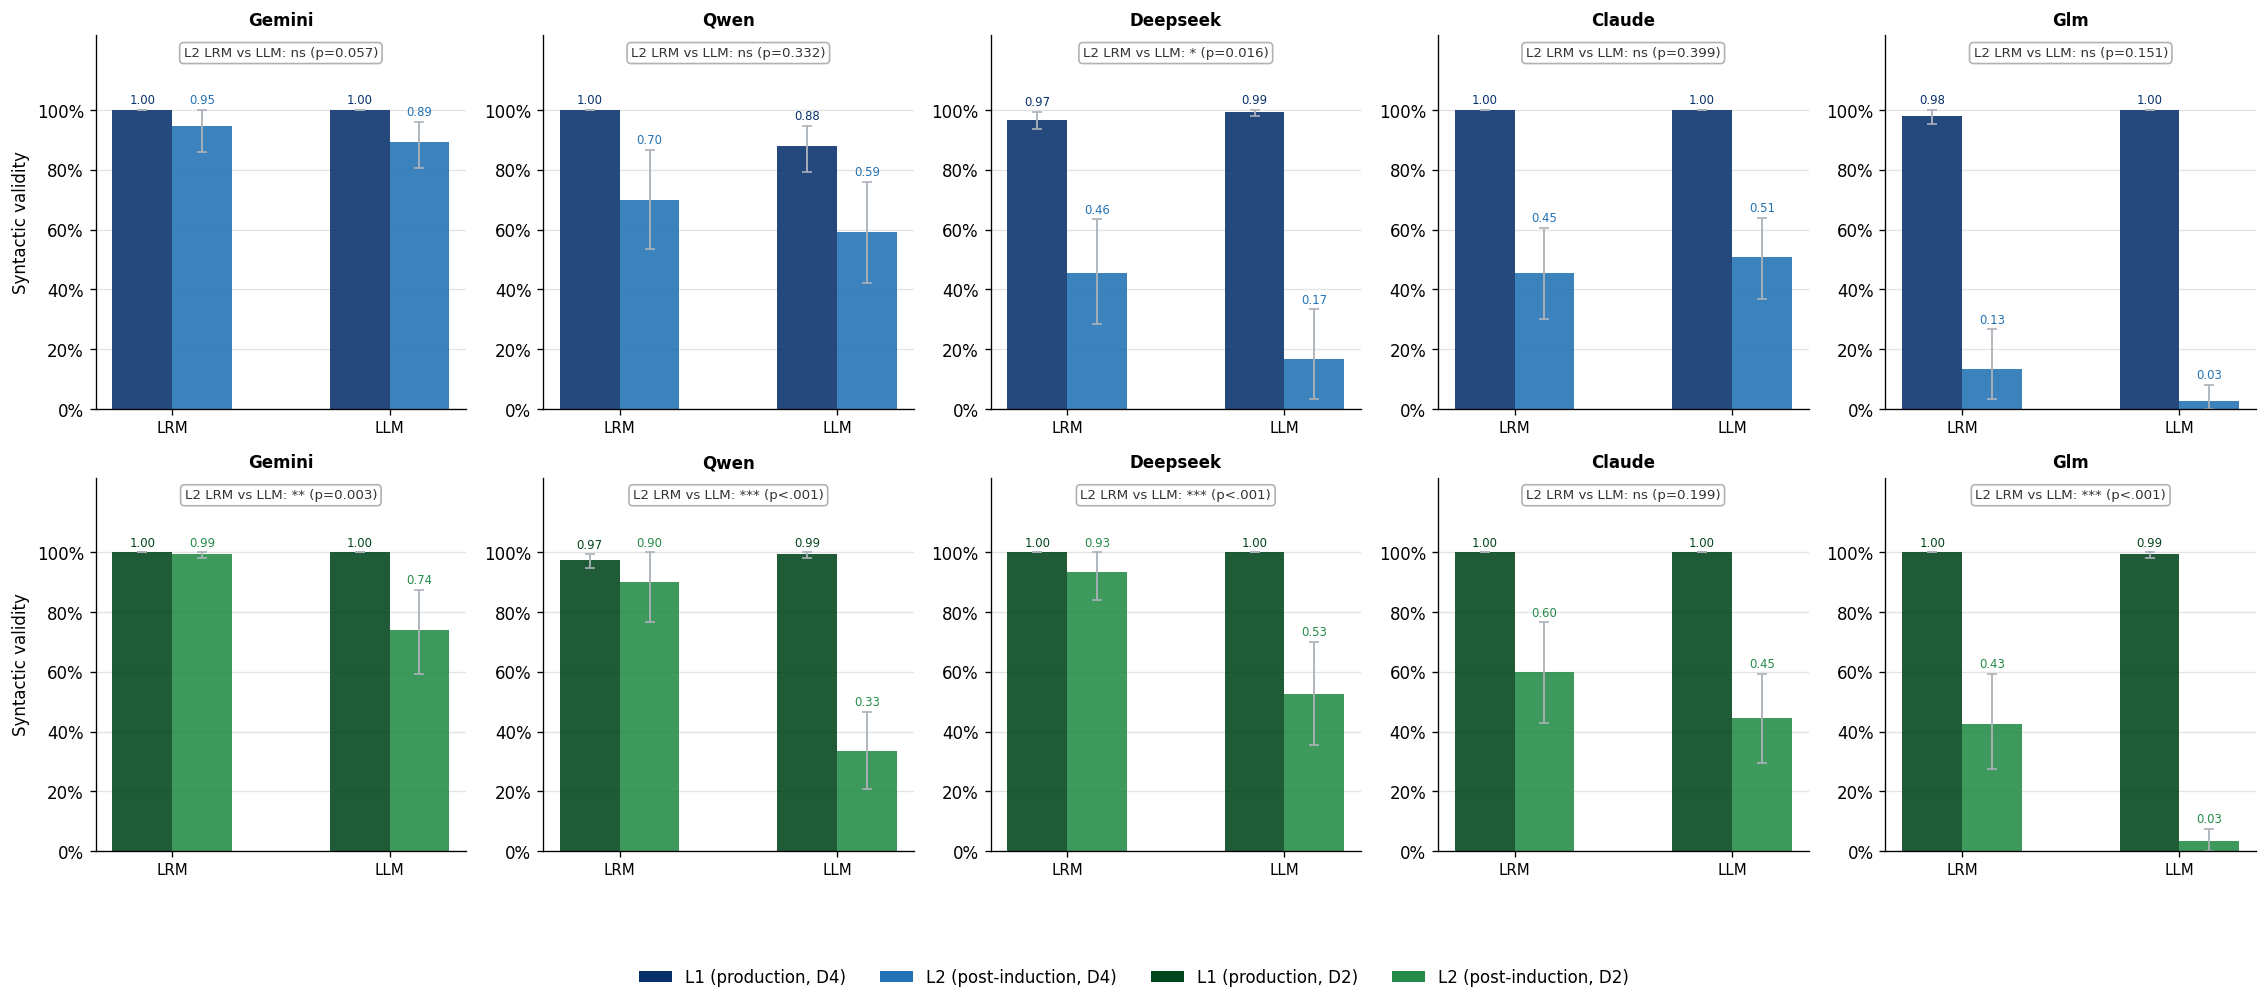

In [11]:

fam_l2_val = {}
for fam, members in FAMILIES.items():
    vals = val_df[val_df['model'].isin(members.values())]['l2_rate'].dropna()
    fam_l2_val[fam] = vals.mean()
fam_order_val = sorted(FAMILIES.keys(), key=lambda f: fam_l2_val[f], reverse=True)

templates_val = ['center_embedding', 'center_embedding_depth2']
BAR_W = 0.22

fig, axes = plt.subplots(
    len(templates_val), len(fam_order_val),
    figsize=(3.8 * len(fam_order_val), 4.0 * len(templates_val)),
    squeeze=False
)

for row_i, tmpl in enumerate(templates_val):
    is_d2    = tmpl == 'center_embedding_depth2'
    l1_color = GRN_D if is_d2 else L2_BASE_C   # dark shade = L1
    l2_color = GRN_L if is_d2 else L1_C         # light shade = L2

    for col_i, fam in enumerate(fam_order_val):
        ax = axes[row_i][col_i]
        members = FAMILIES[fam]

        data = {}
        for mtype in ('LRM', 'LLM'):
            model = members[mtype]
            sub   = val_df[(val_df['template'] == tmpl) & (val_df['model'] == model)]
            data[mtype] = {
                'l1': sub['l1_rate'].dropna().values,
                'l2': sub['l2_rate'].dropna().values,
            }

        base_xs = [0.0, 0.8]
        tick_xs, tick_ls = [], []
        for m_i, mtype in enumerate(('LRM', 'LLM')):
            bx  = base_xs[m_i]
            l1v = data[mtype]['l1']
            l2v = data[mtype]['l2']

            b1 = ax.bar(bx,         l1v.mean() if len(l1v) else 0, BAR_W,
                        color=l1_color, alpha=0.88,
                        yerr=[[bci(l1v)[0]],[bci(l1v)[1]]] if len(l1v)>=2 else [[0],[0]],
                        capsize=3, ecolor=ERR_C, error_kw={'elinewidth': 1.1})
            b2 = ax.bar(bx + BAR_W, l2v.mean() if len(l2v) else 0, BAR_W,
                        color=l2_color, alpha=0.88,
                        yerr=[[bci(l2v)[0]],[bci(l2v)[1]]] if len(l2v)>=2 else [[0],[0]],
                        capsize=3, ecolor=ERR_C, error_kw={'elinewidth': 1.1})
            for bar, col in [(b1, l1_color), (b2, l2_color)]:
                ax.bar_label(bar, fmt='%.2f', padding=2, fontsize=7, color=col)

            tick_xs.append(bx + BAR_W/2)
            tick_ls.append(mtype)

        lrm_l2 = data['LRM']['l2']
        llm_l2 = data['LLM']['l2']
        if len(lrm_l2) >= 2 and len(llm_l2) >= 2:
            _, p = stats.mannwhitneyu(lrm_l2, llm_l2, alternative='two-sided')
            slbl = sig_label(p)
            pstr = 'p<.001' if p < 0.001 else f'p={p:.3f}'
            ax.text(0.5, 0.97, f'L2 LRM vs LLM: {slbl} ({pstr})',
                    ha='center', va='top', transform=ax.transAxes,
                    fontsize=8, color='#333',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#aaa', alpha=0.9))

        ax.set_xticks(tick_xs)
        ax.set_xticklabels(tick_ls, fontsize=9)
        ax.set_ylim(0, 1.25)
        ax.set_ylabel('Syntactic validity' if col_i == 0 else '')
        ax.set_title(fam.title(), fontsize=10, fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

handles = [
    Patch(facecolor=L2_BASE_C, label='L1 (production, D4)'),
    Patch(facecolor=L1_C,      label='L2 (post-induction, D4)'),
    Patch(facecolor=GRN_D,     label='L1 (production, D2)'),
    Patch(facecolor=GRN_L,     label='L2 (post-induction, D2)'),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0),
           ncol=4, frameon=False, fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(f'figures/within_family_l1_vs_l2.pdf', bbox_inches='tight')
plt.show()

In [12]:
print('=' * 65)
print('  Structural Validity: L1 vs L2  (descriptive, no pooled test)')
print('=' * 65)
for tmpl in sorted(val_df['template'].unique()):
    sub = val_df[val_df['template'] == tmpl]
    print('')
    print('  Template: ' + tmpl.replace('_', ' '))
    for stage, col in [('L1', 'l1_rate'), ('L2', 'l2_rate')]:
        lrm = sub[sub['type'] == 'LRM'][col].dropna()
        llm = sub[sub['type'] == 'LLM'][col].dropna()
        print('    %s  LRM mean=%.3f sd=%.3f n=%d  |  LLM mean=%.3f sd=%.3f n=%d'
              % (stage, lrm.mean(), lrm.std(), len(lrm),
                        llm.mean(), llm.std(), len(llm)))
print()

print('Sentence-level counts (all runs pooled):')
sent_counts = (
    val_df.groupby(['template', 'type'])[['l1_valid_n', 'l1_total', 'l2_valid_n', 'l2_total']]
    .sum()
    .assign(l1_pct=lambda x: (x['l1_valid_n'] / x['l1_total'] * 100).round(1),
            l2_pct=lambda x: (x['l2_valid_n'] / x['l2_total'] * 100).round(1))
)
display(sent_counts[['l1_valid_n', 'l1_total', 'l1_pct', 'l2_valid_n', 'l2_total', 'l2_pct']])


  Structural Validity: L1 vs L2  (descriptive, no pooled test)

  Template: center embedding
    L1  LRM mean=0.989 sd=0.045 n=149  |  LLM mean=0.975 sd=0.107 n=150
    L2  LRM mean=0.538 sd=0.480 n=149  |  LLM mean=0.437 sd=0.464 n=150

  Template: center embedding depth2
    L1  LRM mean=0.995 sd=0.032 n=150  |  LLM mean=0.997 sd=0.023 n=150
    L2  LRM mean=0.770 sd=0.407 n=148  |  LLM mean=0.416 sd=0.446 n=150

Sentence-level counts (all runs pooled):


l1_valid_n  l1_total  l1_pct  l2_valid_n  \
template                type                                             
center_embedding        LLM          731       750    97.5         328   
                        LRM          737       745    98.9         401   
center_embedding_depth2 LLM          748       750    99.7         312   
                        LRM          746       750    99.5         570   

                              l2_total  l2_pct  
template                type                    
center_embedding        LLM        750    43.7  
                        LRM        745    53.8  
center_embedding_depth2 LLM        750    41.6  
                        LRM        740    77.0

## 4. Paper figures

Publication-ready figures based on structural validity.


In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats

mpl.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'figure.dpi':       150,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'grid.alpha':       0.35,
    'grid.linewidth':   0.6,
})

TMPL_LABELS = {'center_embedding': 'CE depth 4', 'center_embedding_depth2': 'CE depth 2'}

def bci(vals, n_boot=2000, ci=95):
    """Bootstrap 95% CI. Returns (lo_err, hi_err) relative to mean for asymmetric yerr."""
    if len(vals) < 2:
        return 0.0, 0.0
    vals = np.asarray(vals, dtype=float)
    boots = np.array([np.mean(np.random.choice(vals, len(vals), replace=True))
                      for _ in range(n_boot)])
    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)
    m  = vals.mean()
    return max(0.0, m - lo), max(0.0, hi - m)


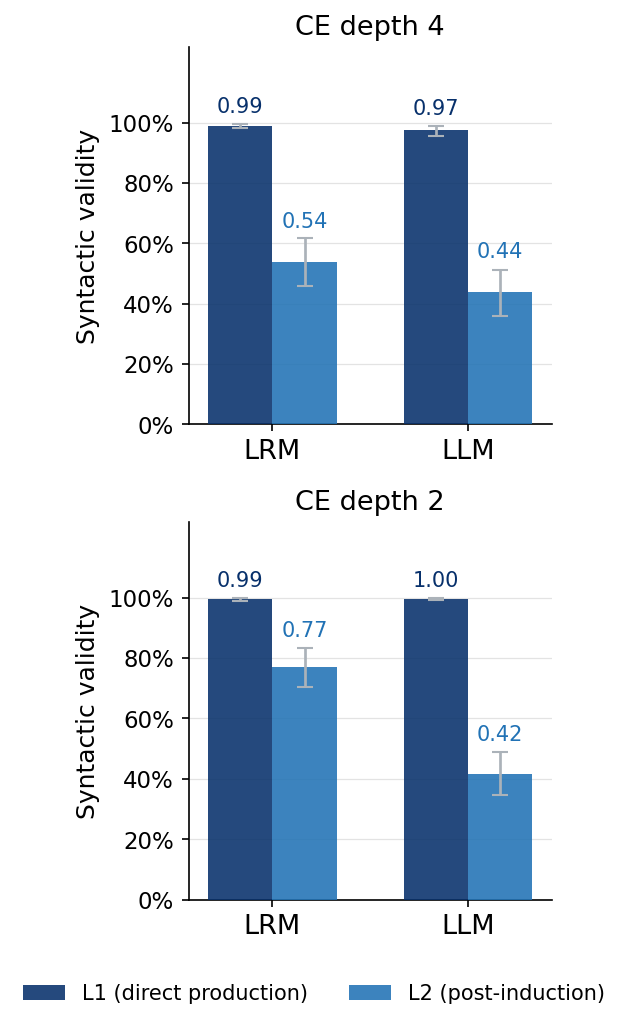

In [14]:
# Figure 1: production–induction gap (L1 vs L2 validity)

PANEL_COLORS = DEPTH_COLORS

fig, axes = plt.subplots(2, 1, figsize=(3.5, 6.5), sharey=True)

for ax, tmpl in zip(axes, TEMPLATES_PAPER):
    sub        = val_df[val_df['template'] == tmpl]
    bar_w, gap = 0.28, 0.85

    for g_i, mtype in enumerate(('LRM', 'LLM')):
        ms  = sub[sub['type'] == mtype]
        l1v = ms['l1_rate'].dropna().values
        l2v = ms['l2_rate'].dropna().values
        x1  = g_i * gap
        x2  = x1 + bar_w

        ax.bar(x1, l1v.mean(), bar_w, color=L2_BASE_C, alpha=0.88,
               yerr=[[bci(l1v)[0]], [bci(l1v)[1]]], capsize=4,
               ecolor=ERR_C, error_kw={'elinewidth': 1.3}, zorder=3)
        ax.bar(x2, l2v.mean(), bar_w, color=L1_C, alpha=0.88,
               yerr=[[bci(l2v)[0]], [bci(l2v)[1]]], capsize=4,
               ecolor=ERR_C, error_kw={'elinewidth': 1.3}, zorder=3)

        ax.text(x1, l1v.mean() + bci(l1v)[1] + 0.025, f'{l1v.mean():.2f}',
                ha='center', va='bottom', fontsize=10, color=L2_BASE_C)
        ax.text(x2, l2v.mean() + bci(l2v)[1] + 0.025, f'{l2v.mean():.2f}',
                ha='center', va='bottom', fontsize=10, color=L1_C)

    ax.set_xticks([bar_w/2, gap + bar_w/2])
    ax.set_xticklabels(['LRM', 'LLM'], fontsize=13)
    ax.set_xlim(-bar_w * 0.8, gap + bar_w * 1.8)
    ax.set_ylim(0, 1.25)
    ax.set_title(TMPL_LABELS[tmpl], fontsize=13)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis='y', labelsize=11)
    ax.set_ylabel('Syntactic validity', fontsize=12)

legend_handles = [
    Patch(facecolor=L2_BASE_C, alpha=0.88, label='L1 (direct production)'),
    Patch(facecolor=L1_C,      alpha=0.88, label='L2 (post-induction)'),
]
fig.legend(handles=legend_handles, loc='upper center',
           bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False, fontsize=10)
plt.tight_layout()
fig.savefig(f'figures/fig1_production_induction_gap.pdf', bbox_inches='tight')
plt.show()


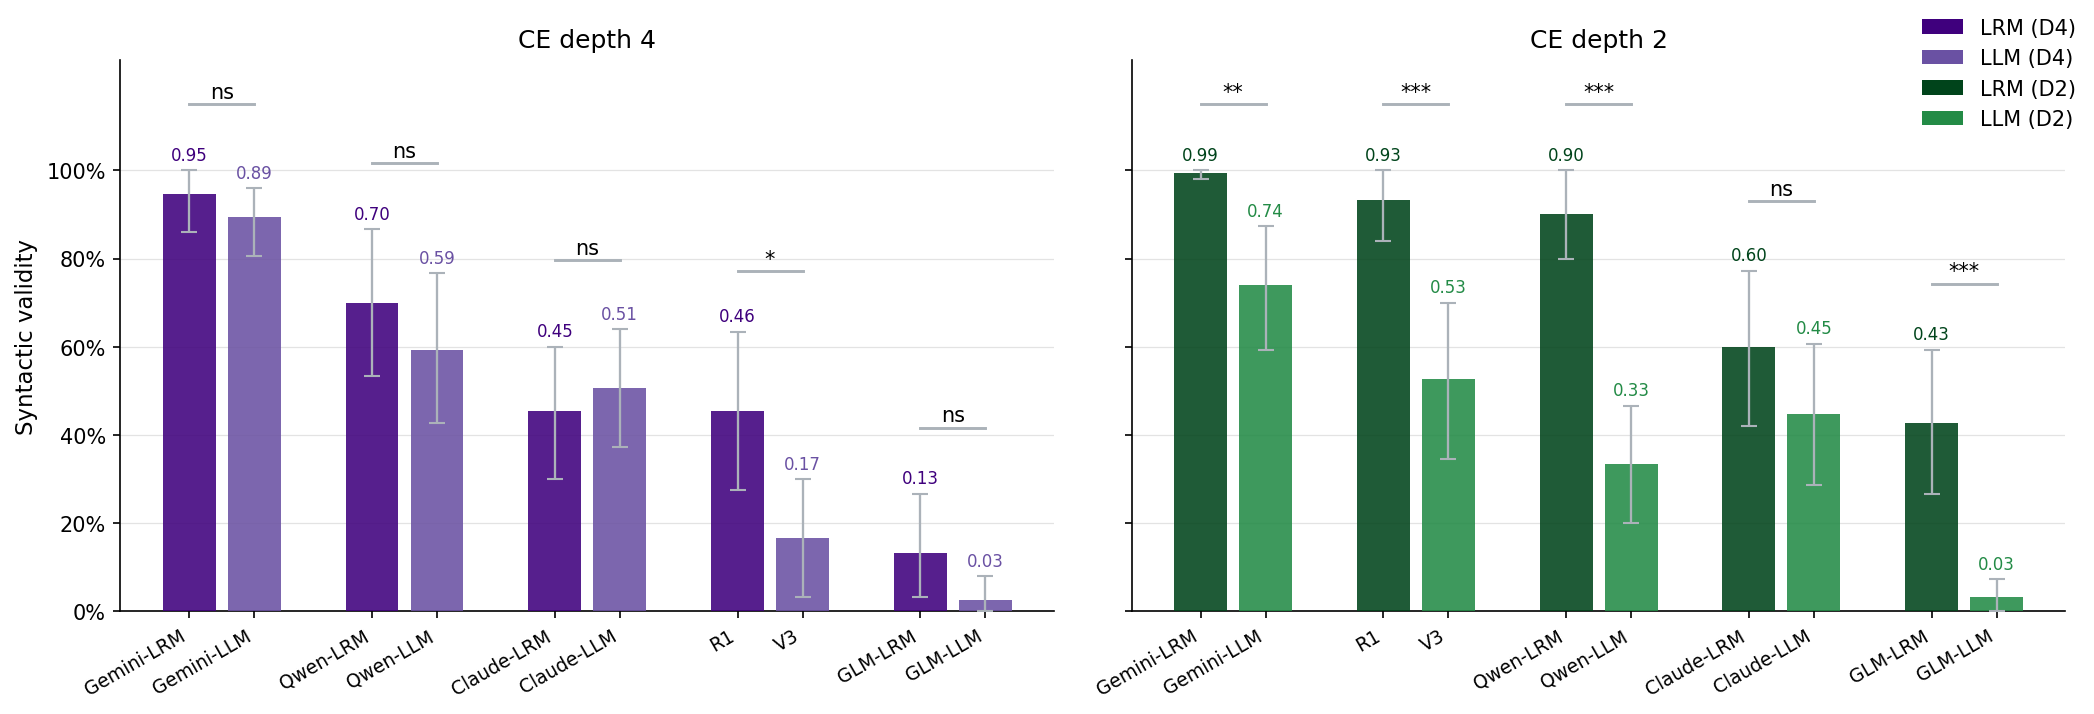

In [15]:
# Figure 2: per-model L2 structural validity

MODEL_LABELS = {
    'deepseek-r1':             'R1',
    'deepseek-v3':             'V3',
    'qwen3-30b-a3b-think':     'Qwen-LRM',
    'qwen3-30b-a3b':           'Qwen-LLM',
    'glm-4.5-think':           'GLM-LRM',
    'glm-4.5':                 'GLM-LLM',
    'claude-sonnet-4.6-think': 'Claude-LRM',
    'claude-sonnet-4.6':       'Claude-LLM',
    'gemini-3.5-flash-think':  'Gemini-LRM',
    'gemini-3.5-flash':        'Gemini-LLM',
}

def sig_bracket_fig2(ax, x1, x2, y, p):
    slbl = sig_label(p)
    h    = 0.03
    ax.plot([x1, x2], [y+h, y+h], lw=1.4, color=ERR_C)
    ax.text((x1+x2)/2, y+h+0.005, slbl, ha='center', va='bottom', fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, tmpl in zip(axes, TEMPLATES_PAPER):
    sub = val_df[val_df['template'] == tmpl]
    is_d2 = tmpl == 'center_embedding_depth2'
    lrm_color = GRN_D if is_d2 else LRM_C
    llm_color = GRN_L if is_d2 else LLM_C

    fam_means = {}
    for fam, members in FAMILIES.items():
        vals = sub[sub['model'].isin(members.values())]['l2_rate'].dropna().values
        fam_means[fam] = vals.mean() if len(vals) else 0
    fam_order = sorted(FAMILIES.keys(), key=lambda f: fam_means[f], reverse=True)

    bar_w  = 0.35
    x_pos  = 0
    tick_xs, tick_ls = [], []

    for fam in fam_order:
        members = FAMILIES[fam]
        xs = {}
        for mtype, color in [('LRM', lrm_color), ('LLM', llm_color)]:
            model = members[mtype]
            vals  = sub[sub['model'] == model]['l2_rate'].dropna().values
            b = ax.bar(x_pos, vals.mean() if len(vals) else 0, bar_w,
                       color=color, alpha=0.88,
                       yerr=[[bci(vals)[0]],[bci(vals)[1]]] if len(vals)>=2 else [[0],[0]],
                       capsize=4, ecolor=ERR_C, error_kw={'elinewidth': 1.1}, zorder=3)
            ax.bar_label(b, fmt='%.2f', padding=3, fontsize=8, color=color)
            tick_xs.append(x_pos)
            tick_ls.append(MODEL_LABELS[model])
            xs[mtype] = (x_pos, vals)
            x_pos += bar_w + 0.08

        lrm_v = xs['LRM'][1]; llm_v = xs['LLM'][1]
        if len(lrm_v) >= 2 and len(llm_v) >= 2:
            _, p = stats.mannwhitneyu(lrm_v, llm_v, alternative='two-sided')
            top  = max(lrm_v.mean() + bci(lrm_v)[1],
                       llm_v.mean() + bci(llm_v)[1]) + 0.12
            sig_bracket_fig2(ax, xs['LRM'][0], xs['LLM'][0], top, p)

        x_pos += 0.35

    ax.set_xticks(tick_xs)
    ax.set_xticklabels(tick_ls, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1.25)
    ax.set_title(TMPL_LABELS[tmpl], fontsize=12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

axes[0].set_ylabel('Syntactic validity')
legend_handles = [
    Patch(facecolor=LRM_C, label='LRM (D4)'),
    Patch(facecolor=LLM_C, label='LLM (D4)'),
    Patch(facecolor=GRN_D, label='LRM (D2)'),
    Patch(facecolor=GRN_L, label='LLM (D2)'),
]
fig.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=10)
plt.tight_layout()
fig.savefig(f'figures/fig2_per_model_l2_validity.pdf', bbox_inches='tight')
plt.show()

## 5. Negative evidence — does it improve L2 validity?

Compares **baseline** (5 correct examples) against **negative evidence** (4 correct + 1 labelled-incorrect example at depth 3). Significance = Mann-Whitney U (two-sided) on per-run L2 validity.


In [16]:
from pathlib import Path

NE_PATH = Path('results_neg_evidence/raw_runs.json')

def _load_dedup(path):
    runs = json.loads(path.read_text())
    seen = {}
    for r in runs:
        if r.get('model_key') not in set(MODEL_ORDER): continue
        if r.get('template') == 'center_embedding_progressive': continue
        key = (r.get('model_key'), r.get('template'), r.get('run_idx'))
        seen[key] = r
    return list(seen.values())

ne_runs = _load_dedup(NE_PATH) if NE_PATH.exists() else []
print(f'Baseline runs : {len(runs)}')
print(f'Neg-evidence  : {len(ne_runs)}')


Baseline runs : 599
Neg-evidence  : 599


In [17]:

def _is_valid_ce_depth3(sentence: str) -> bool:
    """Check whether a sentence is a valid CE structure at depth 3 (9 or 11 words)."""
    return _is_valid_ce(sentence, depth=3)

l1_neg_validation = []
for r in ne_runs:
    tmpl    = r['template']
    model   = r.get('model_key')
    l1_sents = r.get('l1_sentences', [])

    correct_sents = l1_sents[:N_CORRECT_NEG]
    neg_sent      = l1_sents[N_CORRECT_NEG:N_CORRECT_NEG + 1]  # exactly the last intended sentence

    correct_flags = check_validity(correct_sents, tmpl) if correct_sents else []
    neg_flag      = _is_valid_ce_depth3(neg_sent[0]) if neg_sent else False

    all_correct_valid = all(correct_flags) if correct_flags else False
    n_correct_valid   = sum(correct_flags)

    l1_neg_validation.append({
        'model':              model,
        'type':               r.get('model_type'),
        'family':             FAMILY_OF.get(model, 'unknown'),
        'template':           tmpl,
        'run_idx':            r.get('run_idx'),
        'n_correct_valid':    n_correct_valid,
        'n_correct_total':    len(correct_flags),
        'all_correct_valid':  all_correct_valid,
        'neg_sent_valid_d3':  neg_flag,
        'clean_l1':           all_correct_valid and neg_flag,
    })

neg_val_df = pd.DataFrame(l1_neg_validation)

# manipulation check: did models produce the intended L1 structure?
print('Neg-evidence L1 manipulation check')
print('  "Clean L1" = all 4 correct sentences valid at target depth')
print('             + neg sentence valid as a depth-3 CE structure\n')
display(
    neg_val_df.groupby(['template', 'model', 'type'])['clean_l1']
    .mean().round(3).unstack(level=[1, 2])
    .rename(index={'center_embedding': 'Depth 4', 'center_embedding_depth2': 'Depth 2'})
)
print(f'\nOverall clean L1 rate: {neg_val_df["clean_l1"].mean():.1%}')
print(f'Runs with clean L1: {int(neg_val_df["clean_l1"].sum())} / {len(neg_val_df)}')

from collections import defaultdict as _dd
_sc = _dd(lambda: [0, 0])  # [valid, total]
for r in ne_runs:
    tmpl  = r['template']
    depth = 2 if 'depth2' in tmpl else 4
    mtype = r.get('model_type')
    sents = r.get('l1_sentences', [])
    for s in sents[:N_CORRECT_NEG]:
        _sc[(mtype, tmpl)][1] += 1
        _sc[(mtype, tmpl)][0] += int(_is_valid_ce(s, depth))
    if len(sents) > N_CORRECT_NEG:
        _sc[(mtype, tmpl)][1] += 1
        _sc[(mtype, tmpl)][0] += int(_is_valid_ce(sents[N_CORRECT_NEG], depth=3))

print('\nNeg-evidence L1 sentence-level validity (4 correct @ target depth + 1 neg @ depth 3):')
for tmpl, dlabel in [('center_embedding','depth 4'), ('center_embedding_depth2','depth 2')]:
    for mtype in ('LRM', 'LLM'):
        v, t = _sc[(mtype, tmpl)]
        print(f'  {mtype} {dlabel}: {v}/{t} ({v/t*100:.1f}%)')


Neg-evidence L1 manipulation check
  "Clean L1" = all 4 correct sentences valid at target depth
             + neg sentence valid as a depth-3 CE structure



model,claude-sonnet-4.6,claude-sonnet-4.6-think,deepseek-r1,deepseek-v3,gemini-3.5-flash,gemini-3.5-flash-think,glm-4.5,glm-4.5-think,qwen3-30b-a3b,qwen3-30b-a3b-think
type,LLM,LRM,LRM,LLM,LLM,LRM,LLM,LRM,LLM,LRM
template,,,,,,,,,,
Depth 4,0.800,0.967,0.828,0.600,0.867,1.000,0.967,0.967,0.0,0.967
Depth 2,0.533,0.967,0.900,0.567,0.933,0.967,0.000,0.833,0.0,0.833



Overall clean L1 rate: 72.5%
Runs with clean L1: 434 / 599

Neg-evidence L1 sentence-level validity (4 correct @ target depth + 1 neg @ depth 3):
  LRM depth 4: 734/745 (98.5%)
  LLM depth 4: 660/750 (88.0%)
  LRM depth 2: 726/750 (96.8%)
  LLM depth 2: 647/750 (86.3%)


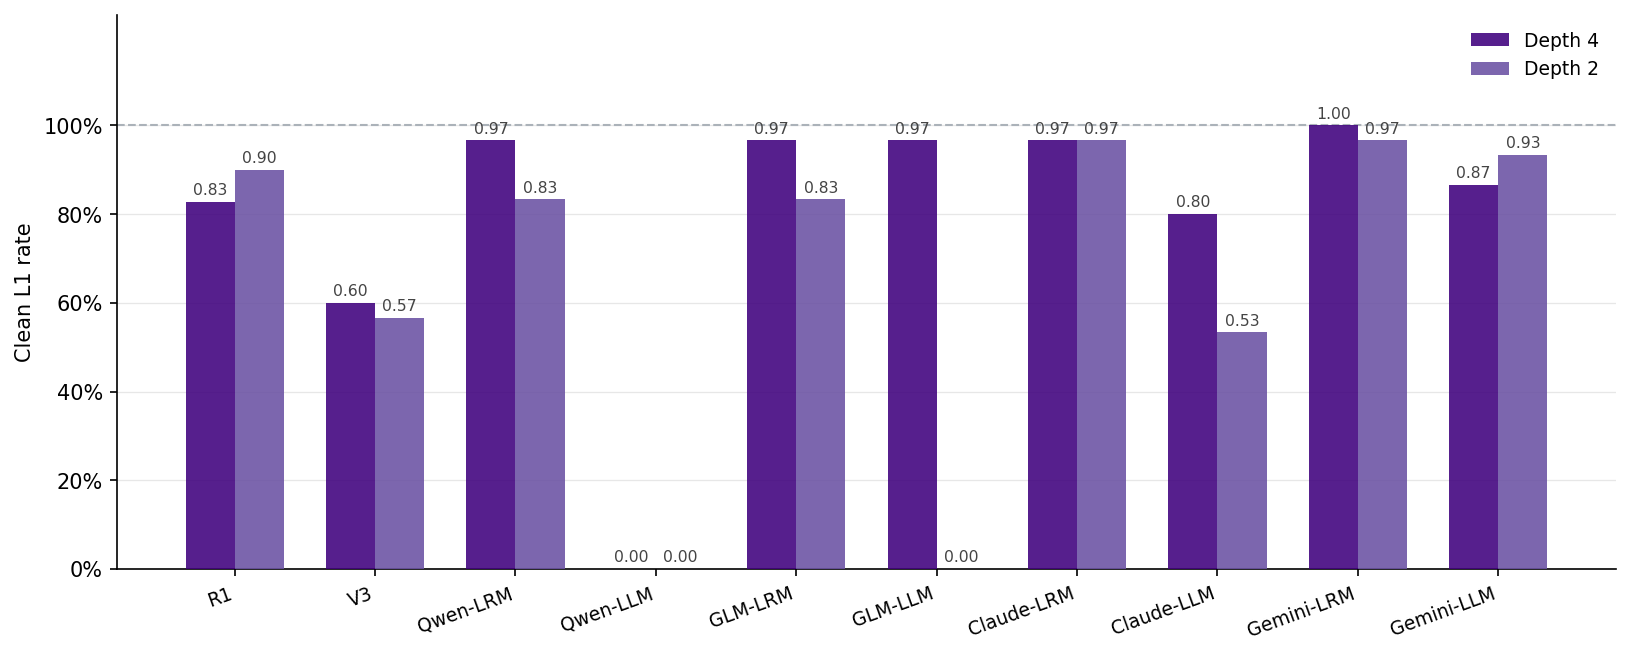

In [27]:
SHORT_NE = {
    'deepseek-r1':             'R1',
    'deepseek-v3':             'V3',
    'qwen3-30b-a3b-think':     'Qwen-LRM',
    'qwen3-30b-a3b':           'Qwen-LLM',
    'glm-4.5-think':           'GLM-LRM',
    'glm-4.5':                 'GLM-LLM',
    'claude-sonnet-4.6-think': 'Claude-LRM',
    'claude-sonnet-4.6':       'Claude-LLM',
    'gemini-3.5-flash-think':  'Gemini-LRM',
    'gemini-3.5-flash':        'Gemini-LLM',
}

_cl = (
    neg_val_df.groupby(['model', 'template'])['clean_l1']
    .mean().reset_index()
)
_cl['depth'] = _cl['template'].map({
    'center_embedding':        'Depth 4',
    'center_embedding_depth2': 'Depth 2',
})

models_with_ne = neg_val_df['model'].unique()
model_order_ne = [m for fam in FAMILIES.values()
                  for m in (fam['LRM'], fam['LLM']) if m in models_with_ne]

depths   = ['Depth 4', 'Depth 2']
D_COLORS = {'Depth 4': PAL_PURPLE[0], 'Depth 2': PAL_PURPLE[1]}
n_models = len(model_order_ne)
BAR_W_cl = 0.35
x        = np.arange(n_models)

fig, ax = plt.subplots(figsize=(11, 4.5))

for d_i, depth in enumerate(depths):
    sub  = _cl[_cl['depth'] == depth].set_index('model')
    vals = [sub.loc[m, 'clean_l1'] if m in sub.index else np.nan for m in model_order_ne]
    offset = (d_i - 0.5) * BAR_W_cl
    bars = ax.bar(x + offset, vals, BAR_W_cl,
                  color=D_COLORS[depth], alpha=0.88, label=depth, zorder=3,
                  ecolor=ERR_C)
    ax.bar_label(bars, fmt='%.2f', padding=2, fontsize=7.5, color='#444')

ax.set_xticks(x)
ax.set_xticklabels([SHORT_NE.get(m, m) for m in model_order_ne],
                   fontsize=9, rotation=20, ha='right')
ax.set_ylabel('Clean L1 rate', fontsize=10)
ax.set_ylim(0, 1.25)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.axhline(1.0, color=ERR_C, lw=1, ls='--')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
fig.savefig(f'figures/neg_evidence_clean_l1_rate.pdf', bbox_inches='tight')
plt.show()

In [19]:
from pathlib import Path

NE_PATH = Path('results_neg_evidence/raw_runs.json')

def _load_dedup(path, allowed_templates=None):
    if not Path(path).exists():
        return []
    raw = json.loads(open(path).read())
    seen = {}
    for r in raw:
        if r.get('model_key') not in set(MODEL_ORDER): continue
        if r.get('template') == 'center_embedding_progressive': continue
        if allowed_templates and r.get('template') not in allowed_templates: continue
        key = (r.get('model_key'), r.get('template'), r.get('run_idx'))
        seen[key] = r
    return list(seen.values())

ne_runs = _load_dedup(NE_PATH)
print(f"Neg-evidence runs loaded: {len(ne_runs)}")

ne_rows = []
for variant_name, variant_list in [('baseline', runs), ('neg_evidence', ne_runs)]:
    for r in variant_list:
        tmpl   = r['template']
        model  = r['model_key']
        mtype  = r.get('model_type')
        family = FAMILY_OF.get(model, 'unknown')
        depth  = 2 if 'depth2' in tmpl else 4

        l2       = r.get('l2_sentences', [])
        l2_flags = check_validity(l2, tmpl) if l2 else []
        l2_rate  = sum(l2_flags)/len(l2_flags) if l2_flags else None

        l1 = r.get('l1_sentences', []) if variant_name == 'baseline' else r.get('l1_sentences', [])[:N_CORRECT_NEG]
        l1_flags = check_validity(l1, tmpl) if l1 else []
        l1_rate  = sum(l1_flags)/len(l1_flags) if l1_flags else None

        ne_rows.append({'variant':variant_name,'model':model,'family':family,
                        'type':mtype,'template':tmpl,'depth':depth,
                        'run_idx':r.get('run_idx'),'l2_rate':l2_rate,'l1_rate':l1_rate})

ne_df = pd.DataFrame(ne_rows)
print("\nMean L2 validity — baseline vs neg_evidence:")
display(ne_df.groupby(['variant','template','type'])['l2_rate'].mean().round(3).unstack())


Neg-evidence runs loaded: 599

Mean L2 validity — baseline vs neg_evidence:


type                                    LLM    LRM
variant      template                             
baseline     center_embedding         0.437  0.538
             center_embedding_depth2  0.416  0.770
neg_evidence center_embedding         0.371  0.633
             center_embedding_depth2  0.172  0.563

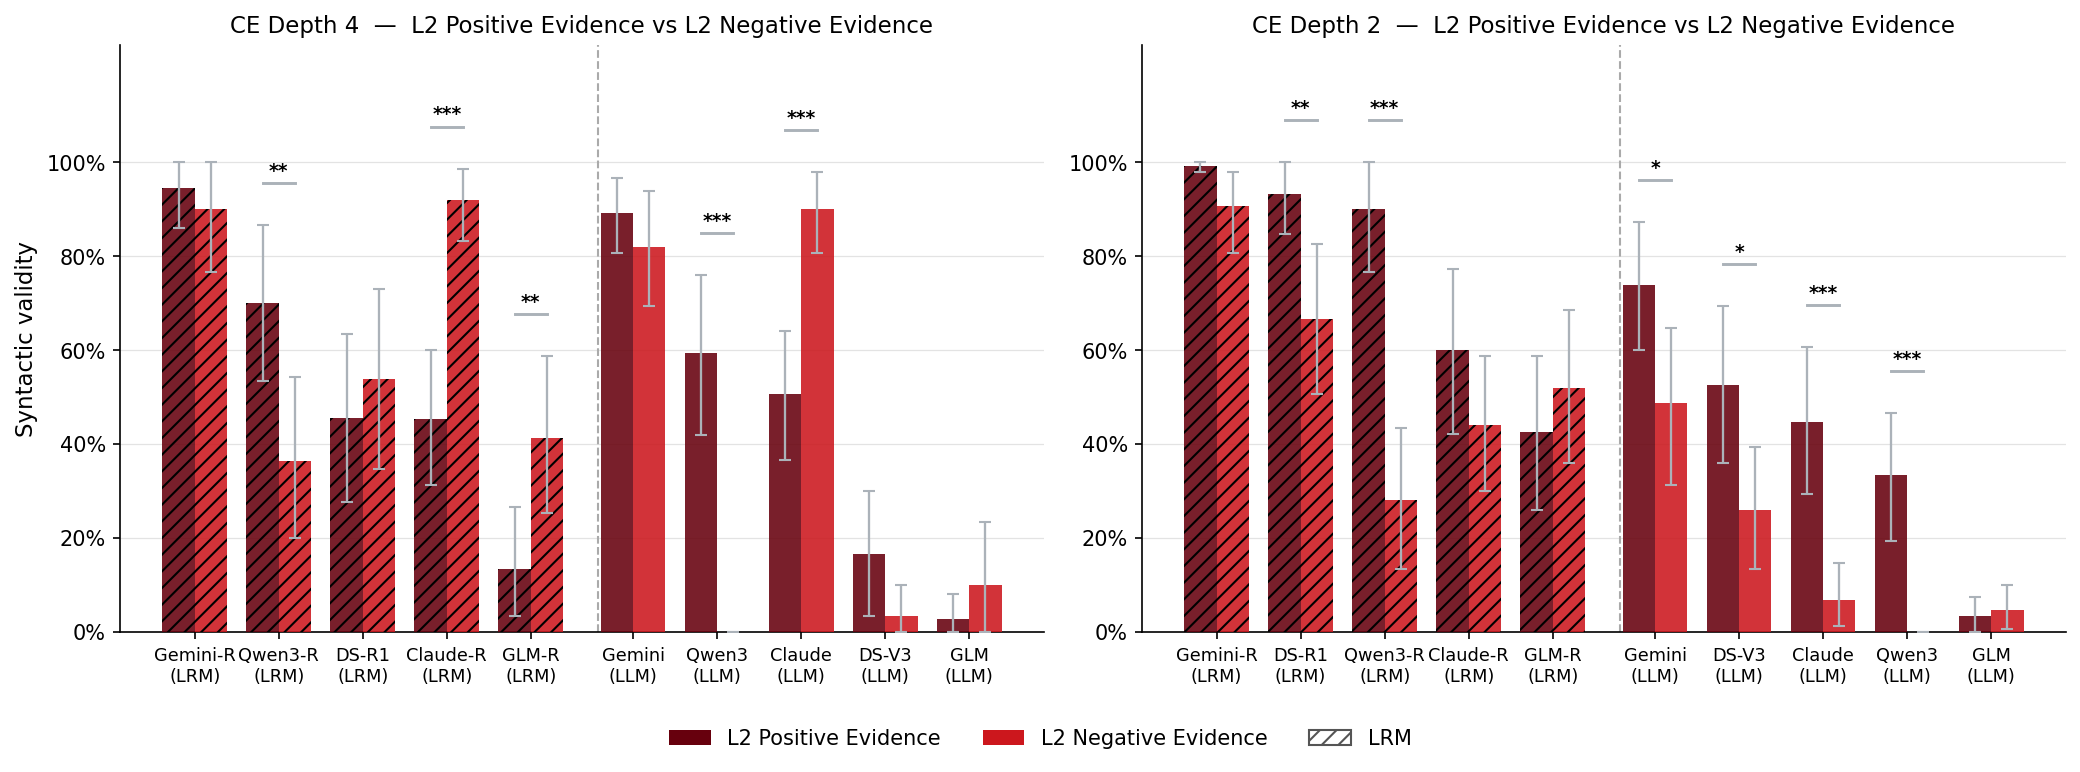

In [20]:

BAR_W  = 0.30

SHORT = {
    'deepseek-r1':             'DS-R1',
    'deepseek-v3':             'DS-V3',
    'qwen3-30b-a3b-think':     'Qwen3-R',
    'qwen3-30b-a3b':           'Qwen3',
    'glm-4.5-think':           'GLM-R',
    'glm-4.5':                 'GLM',
    'claude-sonnet-4.6-think': 'Claude-R',
    'claude-sonnet-4.6':       'Claude',
    'gemini-3.5-flash-think':  'Gemini-R',
    'gemini-3.5-flash':        'Gemini',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for col_i, depth in enumerate([4, 2]):
    ax  = axes[col_i]
    sub = ne_df[ne_df['depth'] == depth]

    lrm_models = [m for m in MODEL_ORDER if m in LRM_MODELS and m in sub['model'].values]
    llm_models = [m for m in MODEL_ORDER if m in LLM_MODELS and m in sub['model'].values]

    def _mean_base(model):
        v = sub[(sub['model']==model) & (sub['variant']=='baseline')]['l2_rate'].dropna().values
        return v.mean() if len(v) else 0

    lrm_models = sorted(lrm_models, key=_mean_base, reverse=True)
    llm_models = sorted(llm_models, key=_mean_base, reverse=True)
    all_models = lrm_models + llm_models

    tick_xs, tick_ls = [], []
    x_offset = 0.0

    for m_i, model in enumerate(all_models):
        mtype  = 'LRM' if model in LRM_MODELS else 'LLM'
        hatch  = '///' if mtype == 'LRM' else ''
        base_v = sub[(sub['model']==model) & (sub['variant']=='baseline')]['l2_rate'].dropna().values
        ne_v   = sub[(sub['model']==model) & (sub['variant']=='neg_evidence')]['l2_rate'].dropna().values

        x_b = x_offset
        x_n = x_offset + BAR_W

        lo_b, hi_b = bci(base_v) if len(base_v)>=2 else (0.,0.)
        lo_n, hi_n = bci(ne_v)   if len(ne_v)>=2   else (0.,0.)
        ax.bar(x_b, base_v.mean() if len(base_v) else 0, BAR_W,
               color=BASE_C, alpha=0.88, hatch=hatch,
               yerr=[[lo_b],[hi_b]], capsize=3,
               ecolor=ERR_C, error_kw={'elinewidth': 1.1}, zorder=3)
        ax.bar(x_n, ne_v.mean()   if len(ne_v)   else 0, BAR_W,
               color=NE_C,   alpha=0.88, hatch=hatch,
               yerr=[[lo_n],[hi_n]], capsize=3,
               ecolor=ERR_C, error_kw={'elinewidth': 1.1}, zorder=3)

        if len(base_v)>=2 and len(ne_v)>=2:
            _, p = stats.mannwhitneyu(base_v, ne_v, alternative='two-sided')
            if p < 0.05:
                slbl = sig_label(p)
                top = max(base_v.mean()+hi_b, ne_v.mean()+hi_n) + 0.07
                h   = 0.02
                ax.plot([x_b, x_n], [top+h, top+h], lw=1.4, color=ERR_C)
                ax.text((x_b+x_n)/2, top+h+0.005, slbl,
                        ha='center', va='bottom', fontsize=9, fontweight='bold')

        tick_xs.append(x_offset + BAR_W/2)
        tick_ls.append(f'{SHORT[model]}\n({mtype})')

        if m_i == len(lrm_models) - 1:
            x_offset += 2*BAR_W + 0.35
            ax.axvline(x_offset - 0.18, color='#aaa', lw=1, ls='--')
        else:
            x_offset += 2*BAR_W + 0.18

    ax.set_xticks(tick_xs)
    ax.set_xticklabels(tick_ls, fontsize=8.5)
    ax.set_ylim(0, 1.25)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_ylabel('Syntactic validity' if col_i == 0 else '')
    ax.set_title(f'CE Depth {depth}  —  L2 Positive Evidence vs L2 Negative Evidence', fontsize=11)
    ax.yaxis.grid(True, alpha=0.35); ax.set_axisbelow(True)

handles = [
    Patch(facecolor=BASE_C, label='L2 Positive Evidence'),
    Patch(facecolor=NE_C,   label='L2 Negative Evidence'),
    Patch(facecolor='white', edgecolor='#555', hatch='///', label='LRM'),
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.0),
           ncol=3, frameon=False, fontsize=10)
plt.tight_layout()
fig.savefig(f'figures/neg_evidence_impact.pdf', bbox_inches='tight')
plt.show()

In [22]:
print('=' * 68)
print('  Negative evidence vs Baseline — L2 structural validity (Mann-Whitney U)')
print('=' * 68)
for depth in [4, 2]:
    print(f'\n  Depth-{depth}:')
    sub = ne_df[ne_df['depth']==depth]
    for mtype in ('LRM','LLM'):
        ms = sub[sub['type']==mtype]
        print(f'    {mtype}:')
        models_ordered = [m for m in MODEL_ORDER if m in ms['model'].values]
        for model in models_ordered:
            base_v = ms[(ms['model']==model)&(ms['variant']=='baseline')]['l2_rate'].dropna().values
            ne_v   = ms[(ms['model']==model)&(ms['variant']=='neg_evidence')]['l2_rate'].dropna().values
            if len(base_v)<2 or len(ne_v)<2: continue
            _, p = stats.mannwhitneyu(base_v, ne_v, alternative='two-sided')
            sig   = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
            delta = ne_v.mean()-base_v.mean()
            arrow = '▲' if delta>0.01 else ('▼' if delta<-0.01 else '≈')
            lo_b,hi_b = bci(base_v); lo_n,hi_n = bci(ne_v)
            print('      %-25s base=%.2f[±%.2f]  ne=%.2f[±%.2f]  %s%.2f  p=%.3f  %s'
                  % (model, base_v.mean(),(lo_b+hi_b)/2, ne_v.mean(),(lo_n+hi_n)/2, arrow, abs(delta), p, sig))


  Negative evidence vs Baseline — L2 structural validity (Mann-Whitney U)

  Depth-4:
    LRM:
      deepseek-r1               base=0.46[±0.17]  ne=0.54[±0.19]  ▲0.08  p=0.431  ns
      qwen3-30b-a3b-think       base=0.70[±0.17]  ne=0.36[±0.17]  ▼0.34  p=0.005  **
      glm-4.5-think             base=0.13[±0.12]  ne=0.41[±0.16]  ▲0.28  p=0.005  **
      claude-sonnet-4.6-think   base=0.45[±0.15]  ne=0.92[±0.08]  ▲0.47  p=0.000  ***
      gemini-3.5-flash-think    base=0.95[±0.07]  ne=0.90[±0.12]  ▼0.05  p=0.621  ns
    LLM:
      deepseek-v3               base=0.17[±0.13]  ne=0.03[±0.05]  ▼0.13  p=0.091  ns
      qwen3-30b-a3b             base=0.59[±0.17]  ne=0.00[±0.00]  ▼0.59  p=0.000  ***
      glm-4.5                   base=0.03[±0.04]  ne=0.10[±0.12]  ▲0.07  p=0.289  ns
      claude-sonnet-4.6         base=0.51[±0.13]  ne=0.90[±0.09]  ▲0.39  p=0.000  ***
      gemini-3.5-flash          base=0.89[±0.08]  ne=0.82[±0.13]  ▼0.07  p=0.992  ns

  Depth-2:
    LRM:
      deepseek-r1     